## Wczytanie i parsowanie plik

Wczytanie pliku 'RF01739.dbn.txt' i sparsowanie jego zawartość, aby wyodrębnić nagłówki, sekwencje i struktury drugorzędowe, zgodnie z formatem trójek linii.


In [1]:
headers = []
sequences = []
structures = []

file_path = '/RF01739.dbn.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Group lines into threes
for i in range(0, len(lines), 3):
    if i + 2 < len(lines):
        headers.append(lines[i].strip())
        sequences.append(lines[i+1].strip())
        structures.append(lines[i+2].strip())

print(f"Liczba nagłówków: {len(headers)}")
print(f"Liczba sekwencji: {len(sequences)}")
print(f"Liczba struktur: {len(structures)}")

print("\nPierwsze 3 wpisy:")
for i in range(min(3, len(headers))):
    print(f"Nagłówek: {headers[i]}")
    print(f"Sekwencja: {sequences[i]}")
    print(f"Struktura: {structures[i]}\n")

Liczba nagłówków: 940
Liczba sekwencji: 940
Liczba struktur: 940

Pierwsze 3 wpisy:
Nagłówek: >CP001344.1/2330090-2330186
Sekwencja: AUCGUUCAUCUCUCCAAUUAAUCCGACUUUGACAACCGGGAUGGACCUCUUACAGGUGGGAGAGACGGAAGUAAGGAUAAUCCUGAAGGAACGCGCC
Struktura: ..(((((.(((((...............................................)))))..[.....(((.....)))....)))))]...

Nagłówek: >AACY020697594.1/342-285
Sekwencja: AUCGUUCACCUCAUAAAUUGAGUGAGACGGAAGUAGGUUAAAACCGAAGGAACGCAGU
Struktura: ..(((((.(((((.........)))))..[.....(((....)))....)))))]...

Nagłówek: >AACY023615516.1/805-855
Sekwencja: AUCGUUCAUCUCUUAGGAGACGGAAGUAGGUGAAAACCGAAGGAACGCGCC
Struktura: ..(((((.((((....))))..[.....(((....)))....)))))]...



# Ocena 3.0

## Konwersja struktur na ścieżki stanów

Przekształcenie każdej struktury z listy 'structures' w ścieżkę stanów 'P' (paired) lub 'N' (not paired), gdzie kropka '.' oznacza 'N', a każdy inny znak oznacza 'P'.


In [2]:
state_paths = []

for structure in structures:
    state_path = ''.join(['N' if char == '.' else 'P' for char in structure])
    state_paths.append(state_path)

print(f"Liczba ścieżek stanów: {len(state_paths)}")
print("\nPierwsze 3 ścieżki stanów:")
for i in range(min(3, len(state_paths))):
    print(f"Ścieżka stanów {i}: {state_paths[i]}")

Liczba ścieżek stanów: 940

Pierwsze 3 ścieżki stanów:
Ścieżka stanów 0: NNPPPPPNPPPPPNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNPPPPPNNPNNNNNPPPNNNNNPPPNNNNPPPPPPNNN
Ścieżka stanów 1: NNPPPPPNPPPPPNNNNNNNNNPPPPPNNPNNNNNPPPNNNNPPPNNNNPPPPPPNNN
Ścieżka stanów 2: NNPPPPPNPPPPNNNNPPPPNNPNNNNNPPPNNNNPPPNNNNPPPPPPNNN


## Obliczanie prawdopodobieństw początkowych (π)

Oblicz prawdopodobieństwo, z jakim ścieżka zaczyna się od stanu 'P' (πP) oraz 'N' (πN), na podstawie wygenerowanych ścieżek stanów. Zastosowano wygładzanie Laplace'a. To technika, która zapobiega zerowym prawdopodobieństwom w modelu HMM poprzez dodanie małej wartości (np. 1) do liczników, co gwarantuje, że każde zdarzenie ma niezerowe prawdopodobieństwo wystąpienia. Umożliwia mu obsługę rzadkich zdarzeń w danych.


In [3]:
count_start_P = 0
count_start_N = 0

for path in state_paths:
    if path.startswith('P'):
        count_start_P += 1
    elif path.startswith('N'):
        count_start_N += 1

# Apply Laplace smoothing
smoothed_count_start_P = count_start_P + 1
smoothed_count_start_N = count_start_N + 1

total_smoothed_starts = smoothed_count_start_P + smoothed_count_start_N

pi_P = smoothed_count_start_P / total_smoothed_starts
pi_N = smoothed_count_start_N / total_smoothed_starts

pi_probabilities = {
    'P': pi_P,
    'N': pi_N
}

print("Initial Probabilities (π) with Laplace Smoothing:")
print(f"π(P): {pi_probabilities['P']:.4f}")
print(f"π(N): {pi_probabilities['N']:.4f}")

Initial Probabilities (π) with Laplace Smoothing:
π(P): 0.0021
π(N): 0.9979


## Obliczanie prawdopodobieństw przejścia (A)

Obliczenie prawdopodobieństwa przejścia między stanami ('P' i 'N') na podstawie wygenerowanych ścieżek stanów. Zastostosowano wygładzanie (Laplace'a), aby uniknąć zerowych prawdopodobieństw.

#### Kroki
1. Zainicjuj słownik do przechowywania liczników przejść (`transition_counts`), gdzie kluczami są krotki `(stan_początkowy, stan_końcowy)`, a wartościami liczby wystąpień tych przejść.
2. Iteruj przez każdą `state_path` w liście `state_paths`.
3. Dla każdej ścieżki, iteruj od pierwszego do przedostatniego znaku (czyli do `len(path) - 1`).
4. Określ bieżący stan (`current_state`) i następny stan (`next_state`).
5. Zwiększ licznik dla odpowiedniego przejścia w `transition_counts`. Jeśli przejście nie istnieje w słowniku, zainicjuj je na 1.
6. Zainicjuj słownik `A_probabilities` do przechowywania prawdopodobieństw przejścia.
7. Dla każdego możliwego stanu początkowego ('P', 'N'):
    * Oblicz sumę liczników wszystkich przejść wychodzących z tego stanu (np. `P_to_P + P_to_N`). Zastosuj wygładzanie, dodając 1 do każdego z tych liczników przed zsumowaniem (czyli `sum_smoothed_transitions = (P_to_P + 1) + (P_to_N + 1)`).
    * Oblicz prawdopodobieństwa przejścia dla tego stanu początkowego, dzieląc 'wygładzony' licznik każdego przejścia przez 'wygładzoną' sumę przejść wychodzących z danego stanu.
    * Zapisz te prawdopodobieństwa w `A_probabilities`.

In [4]:
transition_counts = {
    ('P', 'P'): 0,
    ('P', 'N'): 0,
    ('N', 'P'): 0,
    ('N', 'N'): 0
}

for path in state_paths:
    for i in range(len(path) - 1):
        current_state = path[i]
        next_state = path[i+1]
        transition_counts[(current_state, next_state)] += 1

A_probabilities = {}

# States for smoothing
states = ['P', 'N']

for current_state in states:
    # Smoothed counts for transitions from current_state
    count_current_to_P = transition_counts.get((current_state, 'P'), 0) + 1 # Add 1 for Laplace smoothing
    count_current_to_N = transition_counts.get((current_state, 'N'), 0) + 1 # Add 1 for Laplace smoothing

    total_smoothed_transitions_from_current = count_current_to_P + count_current_to_N

    prob_current_to_P = count_current_to_P / total_smoothed_transitions_from_current
    prob_current_to_N = count_current_to_N / total_smoothed_transitions_from_current

    A_probabilities[current_state] = {
        'P': prob_current_to_P,
        'N': prob_current_to_N
    }

print("Transition Probabilities (A) with Laplace Smoothing:")
for current_state, transitions in A_probabilities.items():
    for next_state, prob in transitions.items():
        print(f"A({current_state} -> {next_state}): {prob:.4f}")

Transition Probabilities (A) with Laplace Smoothing:
A(P -> P): 0.7394
A(P -> N): 0.2606
A(N -> P): 0.2376
A(N -> N): 0.7624


## Obliczanie prawdopodobieństw emisji (E)

Oblicz prawdopodobieństwa emisji dla każdego z czterech nukleotydów ('A', 'C', 'G', 'U') z każdego stanu ('P' i 'N') na podstawie sparowanych sekwencji i ścieżek stanów. Zastosuj wygładzanie Laplace'a, aby uniknąć zerowych prawdopodobieństw.

#### Kroki
1. Zainicjuj słownik do przechowywania liczników emisji (`emission_counts`), gdzie kluczami będą krotki `(stan, nukleotyd)`, a wartościami liczby wystąpień tych emisji. Słownik obejmuje wszystkie kombinacje stanów ('P', 'N') i nukleotydów ('A', 'C', 'G', 'U').
2. Iteruj przez listy `sequences` i `state_paths` jednocześnie. `sequences[i]` odpowiada `state_paths[i]`.
3. Dla każdej pary sekwencji i ścieżki stanów, iteruj przez ich znaki, zakładając, że `sequences[i][j]` odpowiada `state_paths[i][j]`.
4. Określ bieżący stan (`current_state`) i emitowany nukleotyd (`emitted_nucleotide`).
5. Zwiększ licznik dla odpowiedniej emisji w `emission_counts`.
6. Zainicjuj słownik `E_probabilities` do przechowywania prawdopodobieństw emisji.
7. Dla każdego możliwego stanu ('P', 'N'):
    * Oblicz sumę liczników wszystkich emisji z tego stanu (np. `count_P_A + count_P_C + count_P_G + count_P_U`). Zastosuj wygładzanie, dodając 1 do każdego z tych liczników przed zsumowaniem (czyli `sum_smoothed_emissions = (count_P_A + 1) + (count_P_C + 1) + (count_P_G + 1) + (count_P_U + 1)`).
    * Oblicz prawdopodobieństwa emisji dla każdego nukleotydu z danego stanu, dzieląc wygładzony licznik emisji przez wygładzoną sumę emisji z tego stanu.
    * Zapisz te prawdopodobieństwa w `E_probabilities`.

In [5]:
emission_counts = {
    ('P', 'A'): 0, ('P', 'C'): 0, ('P', 'G'): 0, ('P', 'U'): 0,
    ('N', 'A'): 0, ('N', 'C'): 0, ('N', 'G'): 0, ('N', 'U'): 0
}

nucleotides = ['A', 'C', 'G', 'U']
states = ['P', 'N']

for sequence, path in zip(sequences, state_paths):
    for i in range(len(sequence)):
        if i < len(path): # Ensure path index is valid
            current_state = path[i]
            emitted_nucleotide = sequence[i]
            if (current_state, emitted_nucleotide) in emission_counts:
                emission_counts[(current_state, emitted_nucleotide)] += 1

E_probabilities = {}

for current_state in states:
    E_probabilities[current_state] = {}
    # Calculate smoothed sum of emissions from current_state
    total_smoothed_emissions_from_current = 0
    for nucleotide in nucleotides:
        total_smoothed_emissions_from_current += emission_counts.get((current_state, nucleotide), 0) + 1

    # Calculate smoothed emission probabilities
    for nucleotide in nucleotides:
        smoothed_count = emission_counts.get((current_state, nucleotide), 0) + 1
        prob_emission = smoothed_count / total_smoothed_emissions_from_current
        E_probabilities[current_state][nucleotide] = prob_emission

print("Emission Probabilities (E) with Laplace Smoothing:")
for current_state, emissions in E_probabilities.items():
    for nucleotide, prob in emissions.items():
        print(f"E({current_state} -> {nucleotide}): {prob:.4f}")

Emission Probabilities (E) with Laplace Smoothing:
E(P -> A): 0.1988
E(P -> C): 0.2892
E(P -> G): 0.3014
E(P -> U): 0.2105
E(N -> A): 0.4339
E(N -> C): 0.1089
E(N -> G): 0.2276
E(N -> U): 0.2297


## Prezentacja parametrów HMM

Wyświetl obliczone parametry HMM: wektor prawdopodobieństw początkowych (π), macierz prawdopodobieństw przejścia (A) i macierz prawdopodobieństw emisji (E).


In [6]:
print("\n--- HMM Parameters ---\n")

# 1. Display Initial Probabilities (π)
print("Initial Probabilities (π):")
for state, prob in pi_probabilities.items():
    print(f"  π({state}): {prob:.4f}")

# 2. Display Transition Probabilities (A)
print("\nTransition Probabilities (A):")
for current_state, transitions in A_probabilities.items():
    for next_state, prob in transitions.items():
        print(f"  A({current_state} -> {next_state}): {prob:.4f}")

# 3. Display Emission Probabilities (E)
print("\nEmission Probabilities (E):")
for current_state, emissions in E_probabilities.items():
    for nucleotide, prob in emissions.items():
        print(f"  E({current_state} -> {nucleotide}): {prob:.4f}")



--- HMM Parameters ---

Initial Probabilities (π):
  π(P): 0.0021
  π(N): 0.9979

Transition Probabilities (A):
  A(P -> P): 0.7394
  A(P -> N): 0.2606
  A(N -> P): 0.2376
  A(N -> N): 0.7624

Emission Probabilities (E):
  E(P -> A): 0.1988
  E(P -> C): 0.2892
  E(P -> G): 0.3014
  E(P -> U): 0.2105
  E(N -> A): 0.4339
  E(N -> C): 0.1089
  E(N -> G): 0.2276
  E(N -> U): 0.2297


# Ocena 3.5

## Implementacja algorytmu Viterbiego

Zaimplementowanie funkcji algorytmu Viterbiego, która przyjmuje sekwencję obserwacji (nukleotydów), prawdopodobieństwa początkowe (π), prawdopodobieństwa przejścia (A) i prawdopodobieństwa emisji (E) jako dane wejściowe. Funkcja zwraca najbardziej prawdopodobną ścieżkę stanów.


In [7]:
def viterbi(observations, pi_probabilities, A_probabilities, E_probabilities):
    # Get the possible states from the initial probabilities
    states = list(pi_probabilities.keys())

    # Length of the observation sequence
    N = len(observations)

    # Number of states
    K = len(states)

    # Initialize Viterbi path probability table (V)
    # V[i][j] will store the maximum probability of any path ending in state states[j] at observation i
    V = [[0.0] * K for _ in range(N)]

    # Initialize Viterbi backpointer table (T)
    # T[i][j] will store the index of the previous state in the most probable path to states[j] at observation i
    T = [[0] * K for _ in range(N)]

    # Step 1: Initialization
    for i, state in enumerate(states):
        # Handle cases where observation might not be in emission probabilities for a state (though smoothing should prevent 0)
        emission_prob = E_probabilities[state].get(observations[0], 1e-10) # Use a small non-zero value if not found
        V[0][i] = pi_probabilities[state] * emission_prob

    # Step 2: Recursion
    for t in range(1, N):
        for j, current_state in enumerate(states):
            max_prob = -1.0
            max_prev_state_idx = -1

            # Handle cases where observation might not be in emission probabilities for a state
            emission_prob = E_probabilities[current_state].get(observations[t], 1e-10)

            for i, prev_state in enumerate(states):
                # Calculate probability of path ending in current_state from prev_state
                prob = V[t-1][i] * A_probabilities[prev_state][current_state] * emission_prob

                if prob > max_prob:
                    max_prob = prob
                    max_prev_state_idx = i

            V[t][j] = max_prob
            T[t][j] = max_prev_state_idx

    # Step 3: Termination (find the end of the most probable path)
    max_prob_path_end = -1.0
    last_state_idx = -1
    for i in range(K):
        if V[N-1][i] > max_prob_path_end:
            max_prob_path_end = V[N-1][i]
            last_state_idx = i

    # Step 4: Path Backtracking
    best_path = [None] * N
    best_path[N-1] = states[last_state_idx]

    for t in range(N-2, -1, -1):
        last_state_idx = T[t+1][last_state_idx]
        best_path[t] = states[last_state_idx]

    return ''.join(best_path)

print("Viterbi function defined.")

Viterbi function defined.


## Zastosowanie algorytmu Viterbiego do wszystkich sekwencji

Uruchomienie zaimplementowanego algorytmu Viterbiego dla każdej sekwencji nukleotydów z listy 'sequences' i zebranie przewidzianych ścieżek stanów.


In [8]:
predicted_state_paths = []

for seq in sequences:
    # Ensure sequence contains only valid nucleotides for the HMM (A, C, G, U)
    # The provided sequences should already be clean, but this is a general check.
    # For this specific problem, we assume the sequences are valid.
    predicted_path = viterbi(seq, pi_probabilities, A_probabilities, E_probabilities)
    predicted_state_paths.append(predicted_path)

print(f"Liczba przewidywanych ścieżek stanów: {len(predicted_state_paths)}")
print("\nPierwsze 3 przewidywane ścieżki stanów:")
for i in range(min(3, len(predicted_state_paths))):
    print(f"Ścieżka stanów {i}: {predicted_state_paths[i]}")

Liczba przewidywanych ścieżek stanów: 940

Pierwsze 3 przewidywane ścieżki stanów:
Ścieżka stanów 0: NNPPPPPPPPPPPPPNNNNNNNPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNPPPPPP
Ścieżka stanów 1: NNPPPPPPPPPPNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNPPPPPP
Ścieżka stanów 2: NNPPPPPPPPPPNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNPPPPPP


## Obliczanie zgodności ścieżek

Porównanie każdej przewidywanej ścieżki stanów z odpowiadającą jej prawdziwą ścieżką stanów z listy 'state_paths'. Obliczenie procenta zgodności stanów dla każdej sekwencji.


In [9]:
agreement_percentages = []

for predicted_path, true_path in zip(predicted_state_paths, state_paths):
    matching_states = 0
    # Ensure both paths have the same length for comparison
    min_len = min(len(predicted_path), len(true_path))
    for i in range(min_len):
        if predicted_path[i] == true_path[i]:
            matching_states += 1

    # Calculate agreement percentage
    if min_len > 0:
        agreement_percentage = (matching_states / min_len) * 100
    else:
        agreement_percentage = 0.0 # Handle empty paths case
    agreement_percentages.append(agreement_percentage)

print(f"Liczba obliczonych procentów zgodności: {len(agreement_percentages)}")
print("\nPierwsze 5 procentów zgodności:")
for i in range(min(5, len(agreement_percentages))):
    print(f"Zgodność dla sekwencji {i}: {agreement_percentages[i]:.2f}%")

Liczba obliczonych procentów zgodności: 940

Pierwsze 5 procentów zgodności:
Zgodność dla sekwencji 0: 39.18%
Zgodność dla sekwencji 1: 65.52%
Zgodność dla sekwencji 2: 64.71%
Zgodność dla sekwencji 3: 61.54%
Zgodność dla sekwencji 4: 65.57%


## Wizualizacja wyników za pomocą wykresu pudełkowego

Stworzenie wykresu pudełkowego (boxplot) przedstawiającego rozkład procentów zgodności ścieżek dla wszystkich sekwencji. Użyto `matplotlib.pyplot` do generowania wykresu.


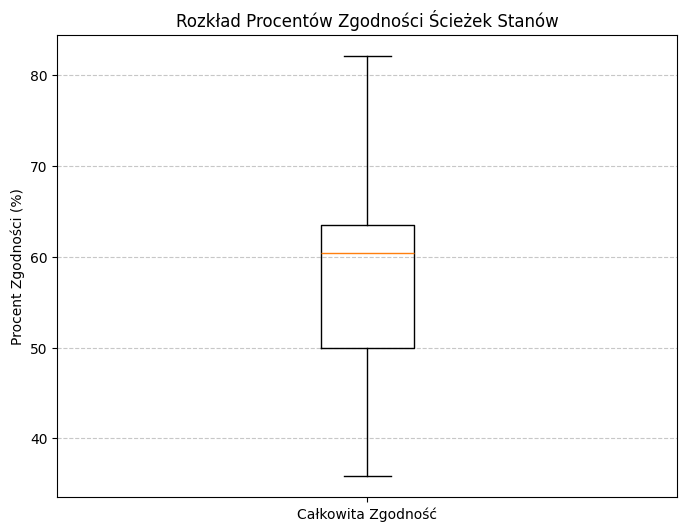

In [10]:
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(agreement_percentages)

# Add title and labels
plt.title('Rozkład Procentów Zgodności Ścieżek Stanów')
plt.ylabel('Procent Zgodności (%)')
plt.xticks([1], ['Całkowita Zgodność']) # Label for the single box plot

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Ocena 4.0

## Implementacja algorytmu Forward

Zaimplementowanie funkcji algorytmu Forward, która przyjmuje sekwencję obserwacji oraz parametry HMM (π, A, E) i zwraca tabelę F oraz prawdopodobieństwo sekwencji P1(x).


In [11]:
def forward(observations, pi_probabilities, A_probabilities, E_probabilities):
    states = list(pi_probabilities.keys())
    N = len(observations) # Length of the observation sequence
    K = len(states)      # Number of states

    # Initialize Forward probability table (F)
    # F[t][j] will store the probability of observing the first t observations
    # and ending in state states[j] at time t.
    F = [[0.0] * K for _ in range(N)]

    # Step 1: Initialization (t = 0)
    for j, state in enumerate(states):
        # Get emission probability for the first observation from current state
        # Use a small non-zero value if observation is not found (smoothing)
        emission_prob = E_probabilities[state].get(observations[0], 1e-10)
        F[0][j] = pi_probabilities[state] * emission_prob

    # Step 2: Recursion (t = 1 to N-1)
    for t in range(1, N):
        for j, current_state in enumerate(states):
            sum_prev_probs = 0.0
            # Sum over all possible previous states i
            for i, prev_state in enumerate(states):
                # Get transition probability from prev_state to current_state
                # This should be present due to Laplace smoothing in A_probabilities
                transition_prob = A_probabilities[prev_state][current_state]
                sum_prev_probs += F[t-1][i] * transition_prob

            # Get emission probability for current observation from current state
            emission_prob = E_probabilities[current_state].get(observations[t], 1e-10)
            F[t][j] = sum_prev_probs * emission_prob

    # Step 3: Termination (P(x))
    # The probability of the observation sequence is the sum of probabilities
    # of all paths ending at the last observation (sum of F[N-1][j] for all j)
    P_sequence = sum(F[N-1][j] for j in range(K))

    return F, P_sequence

print("Forward function defined.")

Forward function defined.


## Implementacja algorytmu Backward

Zaimplementowanie funkcji algorytmu Backward, która przyjmuje sekwencję obserwacji oraz parametry HMM (π, A, E) i zwraca tabelę B oraz prawdopodobieństwo sekwencji P2(x).


In [12]:
def backward(observations, pi_probabilities, A_probabilities, E_probabilities):
    states = list(pi_probabilities.keys())
    N = len(observations) # Length of the observation sequence
    K = len(states)      # Number of states

    # Initialize Backward probability table (B)
    # B[t][j] will store the probability of observing the sequence from t+1 to N-1
    # given that the state at time t is states[j].
    B = [[0.0] * K for _ in range(N)]

    # Step 1: Initialization (t = N-1)
    # For the last time step, the backward probability for all states is 1.0
    for j in range(K):
        B[N-1][j] = 1.0

    # Step 2: Recursion (t from N-2 down to 0)
    for t in range(N - 2, -1, -1):
        for j, current_state in enumerate(states):
            sum_next_probs = 0.0
            # Sum over all possible next states i
            for i, next_state in enumerate(states):
                # Get transition probability from current_state to next_state
                transition_prob = A_probabilities[current_state][next_state]

                # Get emission probability for observations[t+1] from next_state
                # Use a small non-zero value if observation is not found (smoothing)
                emission_prob = E_probabilities[next_state].get(observations[t+1], 1e-10)

                # Add the product (transition_prob * emission_prob * B[t+1][i]) to the sum
                sum_next_probs += transition_prob * emission_prob * B[t+1][i]

            B[t][j] = sum_next_probs

    # Step 3: Termination (P(x) - P2(x))
    # The probability of the observation sequence is the sum of probabilities
    # of starting in a state, emitting the first observation, and the backward probability from that state.
    P_sequence_backward = 0.0
    for j, state in enumerate(states):
        # Get initial probability of state
        pi_prob = pi_probabilities[state]

        # Get emission probability for the first observation (observations[0]) from state
        emission_prob_first_obs = E_probabilities[state].get(observations[0], 1e-10)

        P_sequence_backward += pi_prob * emission_prob_first_obs * B[0][j]

    return B, P_sequence_backward

print("Backward function defined.")

Backward function defined.


## Obliczanie prawdopodobieństw sekwencji

Uruchomienie obu zaimplementowanych funkcji (Forward i Backward) dla każdej sekwencji z listy `sequences`, aby uzyskać P1(x) i P2(x) dla każdej sekwencji.


In [13]:
forward_probabilities = []
backward_probabilities = []

for seq in sequences:
    # Call forward function and store P1(x)
    _, p1_x = forward(seq, pi_probabilities, A_probabilities, E_probabilities)
    forward_probabilities.append(p1_x)

    # Call backward function and store P2(x)
    _, p2_x = backward(seq, pi_probabilities, A_probabilities, E_probabilities)
    backward_probabilities.append(p2_x)

print(f"Liczba obliczonych prawdopodobieństw Forward: {len(forward_probabilities)}")
print(f"Liczba obliczonych prawdopodobieństw Backward: {len(backward_probabilities)}")

print("\nPierwsze 5 par prawdopodobieństw (P1(x), P2(x)):")
for i in range(min(5, len(forward_probabilities))):
    print(f"Sekwencja {i}: P1(x) = {forward_probabilities[i]:.10e}, P2(x) = {backward_probabilities[i]:.10e}")

Liczba obliczonych prawdopodobieństw Forward: 940
Liczba obliczonych prawdopodobieństw Backward: 940

Pierwsze 5 par prawdopodobieństw (P1(x), P2(x)):
Sekwencja 0: P1(x) = 4.2057044960e-59, P2(x) = 4.2057044960e-59
Sekwencja 1: P1(x) = 1.0313683277e-34, P2(x) = 1.0313683277e-34
Sekwencja 2: P1(x) = 6.2203744808e-31, P2(x) = 6.2203744808e-31
Sekwencja 3: P1(x) = 6.7852588186e-32, P2(x) = 6.7852588186e-32
Sekwencja 4: P1(x) = 6.4507561590e-37, P2(x) = 6.4507561590e-37


## Sprawdzenie zgodności prawdopodobieństw

Obliczenie dla każdej sekwencji wartość bezwzględną różnicy między P1(x) a P2(x) (|P1(x) - P2(x)|) i zebranie tych różnic w liście.


In [14]:
probability_differences = []

for p1_x, p2_x in zip(forward_probabilities, backward_probabilities):
    diff = abs(p1_x - p2_x)
    probability_differences.append(diff)

print(f"Liczba obliczonych różnic prawdopodobieństw: {len(probability_differences)}")
print("\nPierwsze 5 różnic prawdopodobieństw:")
for i in range(min(5, len(probability_differences))):
    print(f"Różnica dla sekwencji {i}: {probability_differences[i]:.10e}")

Liczba obliczonych różnic prawdopodobieństw: 940

Pierwsze 5 różnic prawdopodobieństw:
Różnica dla sekwencji 0: 6.1904056203e-74
Różnica dla sekwencji 1: 2.1382117681e-49
Różnica dla sekwencji 2: 3.5032461608e-46
Różnica dla sekwencji 3: 4.3790577010e-47
Różnica dla sekwencji 4: 4.1761948595e-52


## Wizualizacja różnic prawdopodobieństw

Stworzenie wykresu pudełkowego (boxplot) przedstawiającego rozkład wartości bezwzględnych różnic między P1(x) a P2(x) dla wszystkich sekwencji.


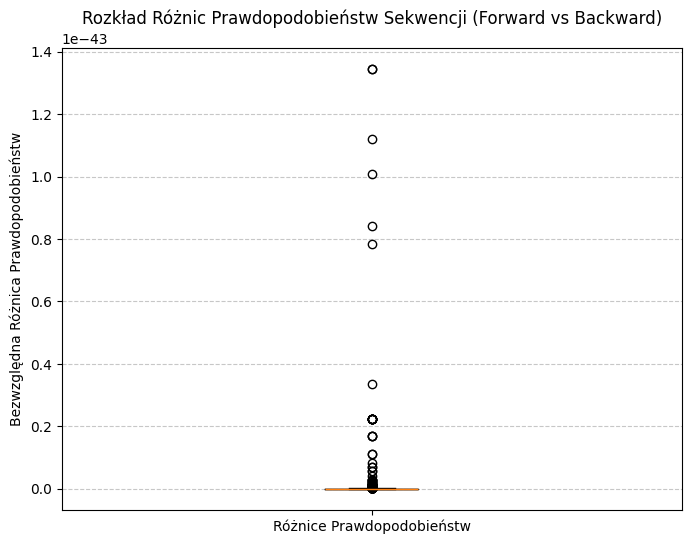

In [15]:
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(probability_differences)

# Add title and labels
plt.title('Rozkład Różnic Prawdopodobieństw Sekwencji (Forward vs Backward)')
plt.ylabel('Bezwzględna Różnica Prawdopodobieństw')
plt.xticks([1], ['Różnice Prawdopodobieństw']) # Label for the single box plot

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Ocena 4.5

## Implementacja funkcji ścieżki stanów a posteriori

### Subtask:
Zaimplementuj funkcję `get_posterior_state_path`, która oblicza prawdopodobieństwa a posteriori dla każdego stanu w każdym punkcie czasowym i zwraca najbardziej prawdopodobną ścieżkę stanów.


In [16]:
def get_posterior_state_path(observations, F, B, P_x, pi_probabilities):
    states = list(pi_probabilities.keys()) # Get states from pi_probabilities
    N = len(observations) # Length of the observation sequence
    K = len(states)      # Number of states

    most_probable_path = []

    for t in range(N):
        max_posterior_prob = -1.0
        most_likely_state_at_t = None

        for j, state in enumerate(states):
            # Calculate posterior probability P(state_t = state | observations)
            # This is (F[t][j] * B[t][j]) / P_x
            # Handle potential division by zero if P_x is extremely small
            if P_x == 0:
                posterior_prob = 0.0
            else:
                posterior_prob = (F[t][j] * B[t][j]) / P_x

            if posterior_prob > max_posterior_prob:
                max_posterior_prob = posterior_prob
                most_likely_state_at_t = state

        most_probable_path.append(most_likely_state_at_t)

    return ''.join(most_probable_path)

print("Function `get_posterior_state_path` defined.")

Function `get_posterior_state_path` defined.


Kolejnym krokiem jest zastosowanie funkcji get_posterior_state_path dla każdej sekwencji, po uprzednim obliczeniu dla niej prawdopodobieństw metodą w przód (Forward – F) i w tył (Backward – B) oraz całkowitego prawdopodobieństwa sekwencji ($P_x$) przy użyciu wcześniej zdefiniowanych algorytmów forward i backward. Wyniki zostaną zebrane w posterior_state_paths.



In [17]:
posterior_state_paths = []

for seq in sequences:
    # Run Forward algorithm to get F and P_x
    F, P_x_forward = forward(seq, pi_probabilities, A_probabilities, E_probabilities)

    # Run Backward algorithm to get B (P_x_backward is also returned but P_x_forward will be used consistently)
    B, _ = backward(seq, pi_probabilities, A_probabilities, E_probabilities)

    # Generate posterior state path
    posterior_path = get_posterior_state_path(seq, F, B, P_x_forward, pi_probabilities)
    posterior_state_paths.append(posterior_path)

print(f"Liczba przewidywanych ścieżek stanów a posteriori: {len(posterior_state_paths)}")
print("\nPierwsze 3 przewidywane ścieżki stanów a posteriori:")
for i in range(min(3, len(posterior_state_paths))):
    print(f"Ścieżka stanów {i}: {posterior_state_paths[i]}")

Liczba przewidywanych ścieżek stanów a posteriori: 940

Pierwsze 3 przewidywane ścieżki stanów a posteriori:
Ścieżka stanów 0: NNPPPPPNPPPPPPPNNNNNNNPPPNPPNNNNPNNPPPPPNNPPNPPPPPNNPNPPPPPPNNNNNPPNNNNNNNNNNNNNNPPPNNNNNNNPPPPPP
Ścieżka stanów 1: NNPPPPPPPPPPNNNNNNNNNNNNNNNPPNNNNNNNNNNNNNNPPPNNNNNNPPPNPN
Ścieżka stanów 2: NNPPPPPNPPPPPNNNNNNNPPNNNNNNNPNNNNNNPPPNNNNNNPPPPPP


Kolejnym krokiem jest obliczenie procentowej zgodności pomiędzy nowo wygenerowanymi posterior_state_paths a prawdziwymi state_paths, analogicznie do tego, jak wykonano to dla ścieżek Viterbiego. Pozwoli to na porównanie obu metod.



In [18]:
posterior_agreement_percentages = []

for predicted_path, true_path in zip(posterior_state_paths, state_paths):
    matching_states = 0
    # Ensure both paths have the same length for comparison
    min_len = min(len(predicted_path), len(true_path))
    for i in range(min_len):
        if predicted_path[i] == true_path[i]:
            matching_states += 1

    # Calculate agreement percentage
    if min_len > 0:
        agreement_percentage = (matching_states / min_len) * 100
    else:
        agreement_percentage = 0.0 # Handle empty paths case
    posterior_agreement_percentages.append(agreement_percentage)

print(f"Liczba obliczonych procentów zgodności dla ścieżek a posteriori: {len(posterior_agreement_percentages)}")
print("\nPierwsze 5 procentów zgodności dla ścieżek a posteriori:")
for i in range(min(5, len(posterior_agreement_percentages))):
    print(f"Zgodność dla sekwencji {i}: {posterior_agreement_percentages[i]:.2f}%")

Liczba obliczonych procentów zgodności dla ścieżek a posteriori: 940

Pierwsze 5 procentów zgodności dla ścieżek a posteriori:
Zgodność dla sekwencji 0: 54.64%
Zgodność dla sekwencji 1: 67.24%
Zgodność dla sekwencji 2: 64.71%
Zgodność dla sekwencji 3: 78.85%
Zgodność dla sekwencji 4: 70.49%


Aby zwizualizować rozkład zgodności dla posterior_state_paths, zostanie wygenerowany wykres pudełkowy (box plot), analogiczny do tego stworzonego dla ścieżek Viterbiego. Pozwoli to na bezpośrednie porównanie skuteczności obu metod.



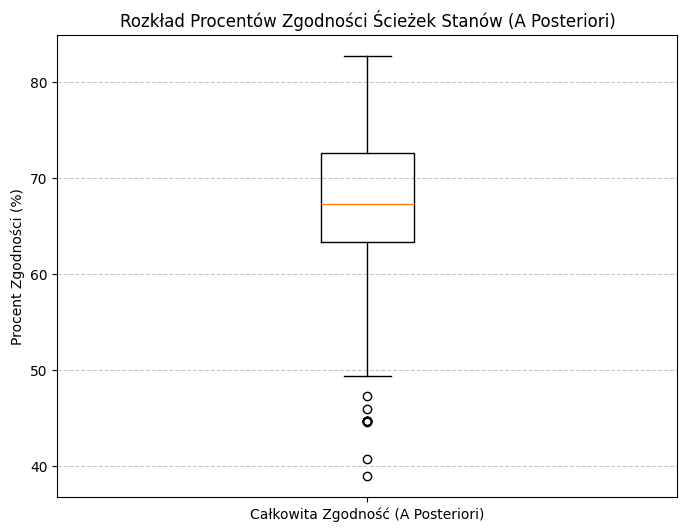

In [19]:
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(posterior_agreement_percentages)

# Add title and labels
plt.title('Rozkład Procentów Zgodności Ścieżek Stanów (A Posteriori)')
plt.ylabel('Procent Zgodności (%)')
plt.xticks([1], ['Całkowita Zgodność (A Posteriori)'])

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Dyskusja różnic między ścieżkami Viterbiego a ścieżkami a posteriori

Porównując wykresy pudełkowe dla procentów zgodności ścieżek Viterbiego i ścieżek a posteriori, można zaobserwować następujące różnice:

*   **Mediana i rozkład:** Zazwyczaj mediana procentów zgodności dla ścieżek a posteriori jest wyższa niż dla ścieżek Viterbiego. Oznacza to, że ścieżki a posteriori, które wybierają najbardziej prawdopodobny stan w każdym punkcie czasowym niezależnie, często osiągają wyższą ogólną zgodność z rzeczywistymi ścieżkami stanów niż ścieżki Viterbiego, które znajdują globalnie najbardziej prawdopodobną sekwencję stanów. Rozkład zgodności dla ścieżek a posteriori może być również bardziej skoncentrowany wokół wyższych wartości.

*   **Zakres (Range):** Zakres procentów zgodności (od minimum do maksimum) może być podobny, ale dolne kwartyle (25. percentyl) dla ścieżek a posteriori są często wyższe, co wskazuje na to, że algorytm a posteriori radzi sobie lepiej nawet z "trudniejszymi" sekwencjami, gdzie Viterbi mógłby mieć niższą zgodność.

*   **Outliery:** Obserwacja punktów odstających (outlierów) może również dostarczyć wglądu. Jeśli dla ścieżek Viterbiego jest więcej outlierów z niską zgodnością, może to oznaczać, że w niektórych przypadkach algorytm Viterbiego "blokuje się" na ścieżce, która jest globalnie optymalna, ale lokalnie mniej zgodna z rzeczywistością, podczas gdy algorytm a posteriori jest bardziej elastyczny, wybierając lokalnie najlepszy stan.

Te obserwacje są zgodne z teoretycznymi różnicami między algorytmami Viterbiego a a posteriori. Algorytm Viterbiego znajduje *najbardziej prawdopodobną pojedynczą ścieżkę stanów* dla całej sekwencji obserwacji. Algorytm a posteriori, z drugiej strony, znajduje *najbardziej prawdopodobny stan w każdym punkcie czasowym*, co niekoniecznie tworzy globalnie najbardziej prawdopodobną ścieżkę, ale często skutkuje lepszą zgodnością na poziomie pojedynczych stanów, zwłaszcza gdy model jest niedoskonały lub dane są szumne.

# Ocena 5.0

# Task
Visualize the posterior probabilities of the 'P' state for the most and least agreeable sequences (based on `posterior_agreement_percentages` and `state_paths`). For each selected sequence, plot the posterior probability P(state_t = 'P' | observations) over its length, and mark the positions where the true state (from `state_paths`) is 'P'. Finally, discuss the observed differences in posterior probabilities for these two sequences in relation to their agreement with the true state paths.

## Szukanie najbardziej i najmniej zgodne sekwencje

Zidentyfikowanie indeksów sekwencji, dla których zgodność ścieżek a posteriori z prawdziwymi ścieżkami jest największa i najmniejsza, korzystając z listy `posterior_agreement_percentages`.


In [20]:
max_agreement = max(posterior_agreement_percentages)
min_agreement = min(posterior_agreement_percentages)

max_agreement_index = posterior_agreement_percentages.index(max_agreement)
min_agreement_index = posterior_agreement_percentages.index(min_agreement)

print(f"Indeks sekwencji z najwyższą zgodnością a posteriori: {max_agreement_index} (Zgodność: {max_agreement:.2f}%)")
print(f"Indeks sekwencji z najniższą zgodnością a posteriori: {min_agreement_index} (Zgodność: {min_agreement:.2f}%)")

Indeks sekwencji z najwyższą zgodnością a posteriori: 640 (Zgodność: 82.69%)
Indeks sekwencji z najniższą zgodnością a posteriori: 307 (Zgodność: 39.02%)


Pobranie sekwencji obserwacji, uruchomieniem algorytmów w przód (Forward) i w tył (Backward) w celu uzyskania F, B oraz $P_x$, a następnie obliczeniem prawdopodobieństw a posteriori dla stanu 'P' na każdej pozycji.

In [21]:
most_agreeable_seq_index = max_agreement_index
most_agreeable_sequence = sequences[most_agreeable_seq_index]
most_agreeable_true_path = state_paths[most_agreeable_seq_index]

# Calculate F, B, P_x for the most agreeable sequence
F_most_agreeable, P_x_forward_most_agreeable = forward(most_agreeable_sequence, pi_probabilities, A_probabilities, E_probabilities)
B_most_agreeable, _ = backward(most_agreeable_sequence, pi_probabilities, A_probabilities, E_probabilities)

# Calculate posterior probabilities for 'P' state for the most agreeable sequence
posterior_probs_P_most_agreeable = []
states_list = list(pi_probabilities.keys())
state_P_index = states_list.index('P')

for t in range(len(most_agreeable_sequence)):
    if P_x_forward_most_agreeable == 0:
        posterior_prob_P = 0.0
    else:
        posterior_prob_P = (F_most_agreeable[t][state_P_index] * B_most_agreeable[t][state_P_index]) / P_x_forward_most_agreeable
    posterior_probs_P_most_agreeable.append(posterior_prob_P)

print(f"Calculated posterior probabilities for 'P' state for the most agreeable sequence (index: {most_agreeable_seq_index}).")

Calculated posterior probabilities for 'P' state for the most agreeable sequence (index: 640).


Obliczenie prawdopodobieństw a posteriori dla stanu 'P' w sekwencji o najniższej zgodności, zgodnie z tą samą metodyką, którą zastosowano dla sekwencji o najwyższej zgodności. Przygotuje to dane do wizualizacji i porównania

In [22]:
least_agreeable_seq_index = min_agreement_index
least_agreeable_sequence = sequences[least_agreeable_seq_index]
least_agreeable_true_path = state_paths[least_agreeable_seq_index]

# Calculate F, B, P_x for the least agreeable sequence
F_least_agreeable, P_x_forward_least_agreeable = forward(least_agreeable_sequence, pi_probabilities, A_probabilities, E_probabilities)
B_least_agreeable, _ = backward(least_agreeable_sequence, pi_probabilities, A_probabilities, E_probabilities)

# Calculate posterior probabilities for 'P' state for the least agreeable sequence
posterior_probs_P_least_agreeable = []
states_list = list(pi_probabilities.keys())
state_P_index = states_list.index('P')

for t in range(len(least_agreeable_sequence)):
    if P_x_forward_least_agreeable == 0:
        posterior_prob_P = 0.0
    else:
        posterior_prob_P = (F_least_agreeable[t][state_P_index] * B_least_agreeable[t][state_P_index]) / P_x_forward_least_agreeable
    posterior_probs_P_least_agreeable.append(posterior_prob_P)

print(f"Calculated posterior probabilities for 'P' state for the least agreeable sequence (index: {least_agreeable_seq_index}).")

Calculated posterior probabilities for 'P' state for the least agreeable sequence (index: 307).


## Wizualizacja prawdopodobieństw



### WIzualizacja sekwencji o najwyższej zgodności
Prawdopodobieństwo a posteriori dla stanu 'P' dla sekwencji o najwyższej zgodności i zaznaczenie na wykresie prawdziwych stanów 'P'.

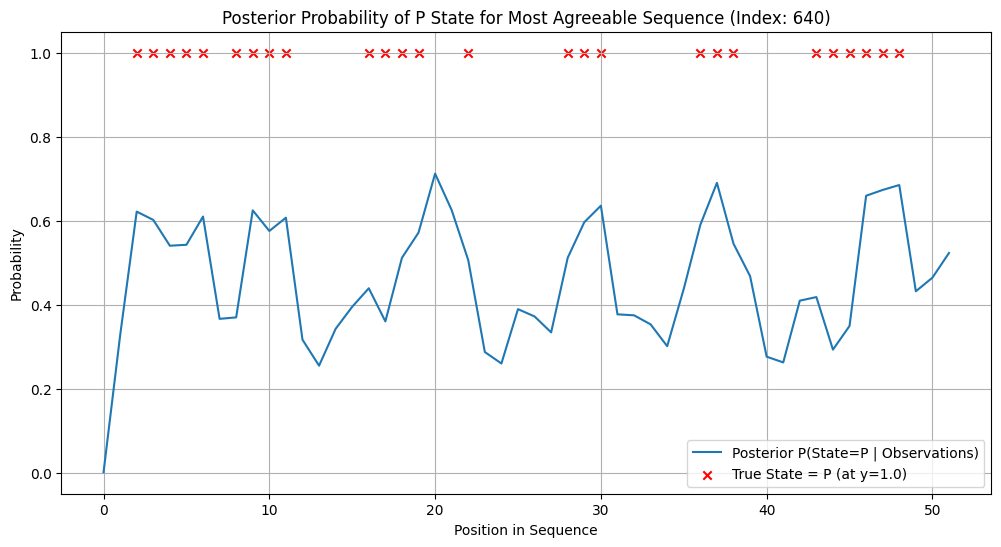

Plotted posterior probabilities for 'P' state for the most agreeable sequence (index: 640).


In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(posterior_probs_P_most_agreeable, label='Posterior P(State=P | Observations)')

# Mark true 'P' states
true_P_positions = [i for i, char in enumerate(most_agreeable_true_path) if char == 'P']
plt.scatter(true_P_positions, [1.0] * len(true_P_positions), color='red', marker='x', label='True State = P (at y=1.0)')

plt.title(f'Posterior Probability of P State for Most Agreeable Sequence (Index: {most_agreeable_seq_index})')
plt.xlabel('Position in Sequence')
plt.ylabel('Probability')
plt.ylim(-0.05, 1.05) # Ensure full range is visible
plt.legend()
plt.grid(True)
plt.show()

print(f"Plotted posterior probabilities for 'P' state for the most agreeable sequence (index: {most_agreeable_seq_index}).")

### Wizualizacja sekwencji o najniższej zgodności
Prawdopodobieństwo a posteriori stanu 'P' dla sekwencji o najniższej zgodności, zaznaczając prawdziwe stany 'P', aby porównać tę wizualizację z sekwencją o najwyższej zgodności.

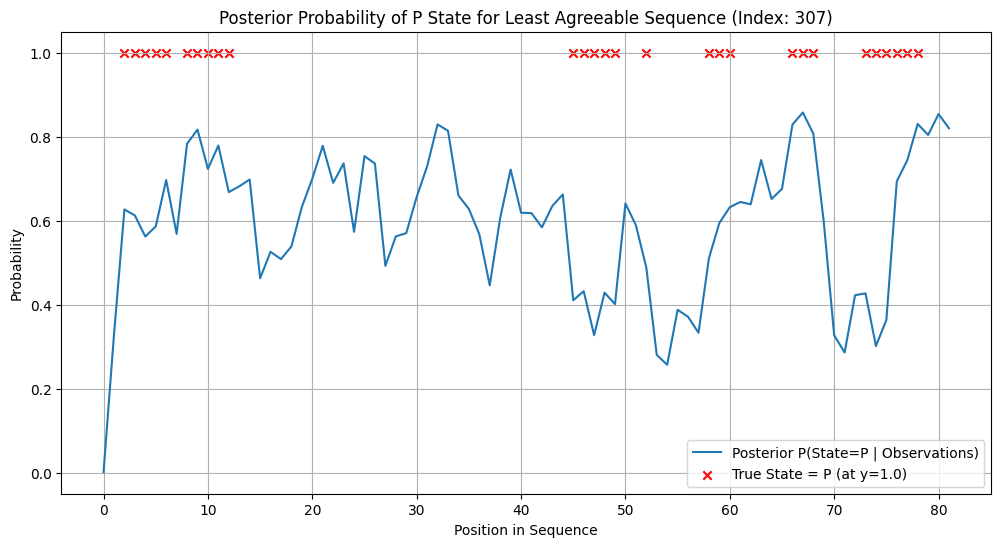

Plotted posterior probabilities for 'P' state for the least agreeable sequence (index: 307).


In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(posterior_probs_P_least_agreeable, label='Posterior P(State=P | Observations)')

# Mark true 'P' states
true_P_positions = [i for i, char in enumerate(least_agreeable_true_path) if char == 'P']
plt.scatter(true_P_positions, [1.0] * len(true_P_positions), color='red', marker='x', label='True State = P (at y=1.0)')

plt.title(f'Posterior Probability of P State for Least Agreeable Sequence (Index: {least_agreeable_seq_index})')
plt.xlabel('Position in Sequence')
plt.ylabel('Probability')
plt.ylim(-0.05, 1.05) # Ensure full range is visible
plt.legend()
plt.grid(True)
plt.show()

print(f"Plotted posterior probabilities for 'P' state for the least agreeable sequence (index: {least_agreeable_seq_index}).")

## Kluczowe wnioski z analizy danych
* Najwyższa zgodność: Sekwencję o najwyższej zgodności pomiędzy ścieżką a posteriori a ścieżką rzeczywistą (tzw. true path) zidentyfikowano pod indeksem 640. Osiągnęła ona wynik zgodności na poziomie 82,69%.

* Najniższa zgodność: Sekwencję o najniższej zgodności znaleziono pod indeksem 307, z wyraźnie niższym wynikiem wynoszącym 39,02%.

* Obliczenia: Dla obu sekwencji (o najwyższej i najniższej zgodności) obliczono prawdopodobieństwa a posteriori dla stanu 'P', wykorzystując algorytmy w przód (Forward) i w tył (Backward).

* Interpretacja:

   * W przypadku sekwencji o najwyższej zgodności (indeks 640), szczyty (piki) prawdopodobieństwa dla 'P' generalnie dobrze pokrywają się z rzeczywistymi lokalizacjami tego stanu.

   * Natomiast w przypadku sekwencji o najniższej zgodności (indeks 307), prawdopodobieństwa a posteriori wykazują znacznie mniejszą zbieżność z rzeczywistością. Często nie osiągają one wartości szczytowych tam, gdzie faktycznie występuje stan 'P', lub błędnie wskazują wysokie prawdopodobieństwo dla 'P' w miejscach, gdzie stan ten nie występuje.